**Identifying Risk**

Q3 — Which hospitals have an Excess Readmission Ratio above 1.0 across multiple conditions simultaneously?
Definition: Excess Readmission Ratio = actual readmissions ÷ expected readmissions. Above 1.0 means the hospital readmits more patients than expected for its patient population. CMS penalizes these hospitals financially.
A hospital above 1.0 on just one condition might be unlucky. A hospital above 1.0 on four conditions has a systemic problem.

Q4 — Which hospitals have both high readmission rates AND high patient safety incidents (PSI scores)?
Definition: PSI = Patient Safety Indicator — events like hospital-acquired pressure ulcers, post-operative blood clots, or falls that represent preventable harm during a hospital stay.
These two together suggest a hospital that both harms patients during the stay AND sends them home before they're ready.

Q5 — Which hospitals spend significantly above the national average but have worse-than-average outcomes?
Definition: spending per episode = total Medicare cost for one complete care episode including pre-admission, hospital stay, and 30-day post-discharge period.
High spending + poor outcomes is the worst combination — it means the hospital is inefficient AND harmful. High spending + good outcomes is a different conversation.

### Which hospitals have an Excess Readmission Ratio above 1.0 across multiple conditions simultaneously? 
#### Excess Readmission Ratio = actual (predicted) readmissions / expected readmissions.

Checking each hospital , on 6 conditions if they have a value above 1 then this hospital has systemic problem.
Ratio > 1.0 (Penalty): This means the hospital had more readmissions than "expected" for an average hospital with similar patients.

#### What are those conditions ? 

1. Acute Myocardial Infarction (AMI)
2. Heart Failure (HF)
3. Pneumonia (PN)
4. Chronic Obstructive Pulmonary Disease (COPD)
5. Elective Primary Total Hip Arthroplasty and/or Total Knee Arthroplasty (THA/TKA)
6. Coronary Artery Bypass Graft (CABG) Surgery 

#### What is the penality ? 

The CMS Hospital Readmissions Reduction Program (HRRP) penalizes acute care hospitals with excess 30-day readmissions for specific conditions, reducing Medicare payments by up to 3%. Penalties are based on risk-adjusted, peer-grouped performance focusing on heart attack, heart failure, pneumonia, COPD, hip/knee replacements, and CABG surgery.

*For this question i'm going to work on ratio columns because CMS already calculated the predicted/ expected redmissions*

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import numpy as np

In [82]:
general_info = pd.read_csv('general_info_cleaned.csv')
readmissions = pd.read_csv('readmissions_cleaned.csv')

readmissions['facility_id'] = readmissions['facility_id'].astype(str).str.zfill(6)
general_info['facility_id'] = general_info['facility_id'].astype(str).str.zfill(6)

ratio_cols = [
    'readm_ratio_readm_30_ami_hrrp',      
    'readm_ratio_readm_30_cabg_hrrp',       
    'readm_ratio_readm_30_copd_hrrp',       
    'readm_ratio_readm_30_hf_hrrp',     
    'readm_ratio_readm_30_hip_knee_hrrp',  
    'readm_ratio_readm_30_pn_hrrp'      
]

for col in ratio_cols:
    readmissions[col] = pd.to_numeric(readmissions[col], errors='coerce')

readmissions['conditions'] = (readmissions[ratio_cols] > 1).sum(axis=1)

systemic_hospitals = readmissions[readmissions['conditions'] >= 4].copy() 

In [83]:


systemic_hospitals['avg_ratio'] = systemic_hospitals[ratio_cols].mean(axis=1)

systemic_hospitals_sorted = (
    systemic_hospitals
    .sort_values(['conditions', 'avg_ratio'], ascending=[False, False])
    .reset_index(drop=True)
    .head(10)
    .merge(
        general_info[['facility_id', 'facility_name', 'state', 'hospital_type']],
        on='facility_id', how='left'
    )
)
systemic_hospitals_sorted[['facility_id', 'facility_name', 'state', 'hospital_type', 'conditions'] + ratio_cols]



,facility_id,facility_name,state,hospital_type,conditions,readm_ratio_readm_30_ami_hrrp,readm_ratio_readm_30_cabg_hrrp,readm_ratio_readm_30_copd_hrrp,readm_ratio_readm_30_hf_hrrp,readm_ratio_readm_30_hip_knee_hrrp,readm_ratio_readm_30_pn_hrrp
0,100007,ADVENTHEALTH ORLANDO,FL,Acute Care Hospitals,6,1.1646,1.2228,1.1015,1.1447,1.0810,1.1409
1,220116,TUFTS MEDICAL CENTER,MA,Acute Care Hospitals,6,1.2234,1.1181,1.0662,1.0288,1.3777,1.0218
2,230041,MCLAREN BAY REGION,MI,Acute Care Hospitals,6,1.1073,1.3880,1.0750,1.0889,1.1646,1.0066
3,100238,HCA FLORIDA NORTHSIDE HOSPITAL,FL,Acute Care Hospitals,6,1.0686,1.1224,1.1610,1.0985,1.2092,1.1562
4,220012,CAPE COD HOSPITAL,MA,Acute Care Hospitals,6,1.0987,1.0438,1.0473,1.1149,1.2925,1.0957
5,390115,JEFFERSON HEALTH- NORTHEAST,PA,Acute Care Hospitals,6,1.0959,1.1005,1.1018,1.2197,1.0699,1.0699
6,240053,PARK NICOLLET METHODIST HOSPITAL,MN,Acute Care Hospitals,6,1.1061,1.1310,1.0057,1.0538,1.2500,1.0721
7,040027,BAXTER HEALTH,AR,Acute Care Hospitals,6,1.0924,1.2015,1.0863,1.0098,1.1658,1.0432
8,230141,MCLAREN FLINT,MI,Acute Care Hospitals,6,1.0779,1.1638,1.0210,1.0148,1.2316,1.0345
9,490048,LEWISGALE MEDICAL CENTER,VA,Acute Care Hospitals,6,1.0920,1.1148,1.0309,1.1404,1.0973,1.0131


In [84]:
print(systemic_hospitals['conditions'].value_counts().sort_index())


conditions
4    314
5    139
6     17
Name: count, dtype: int64


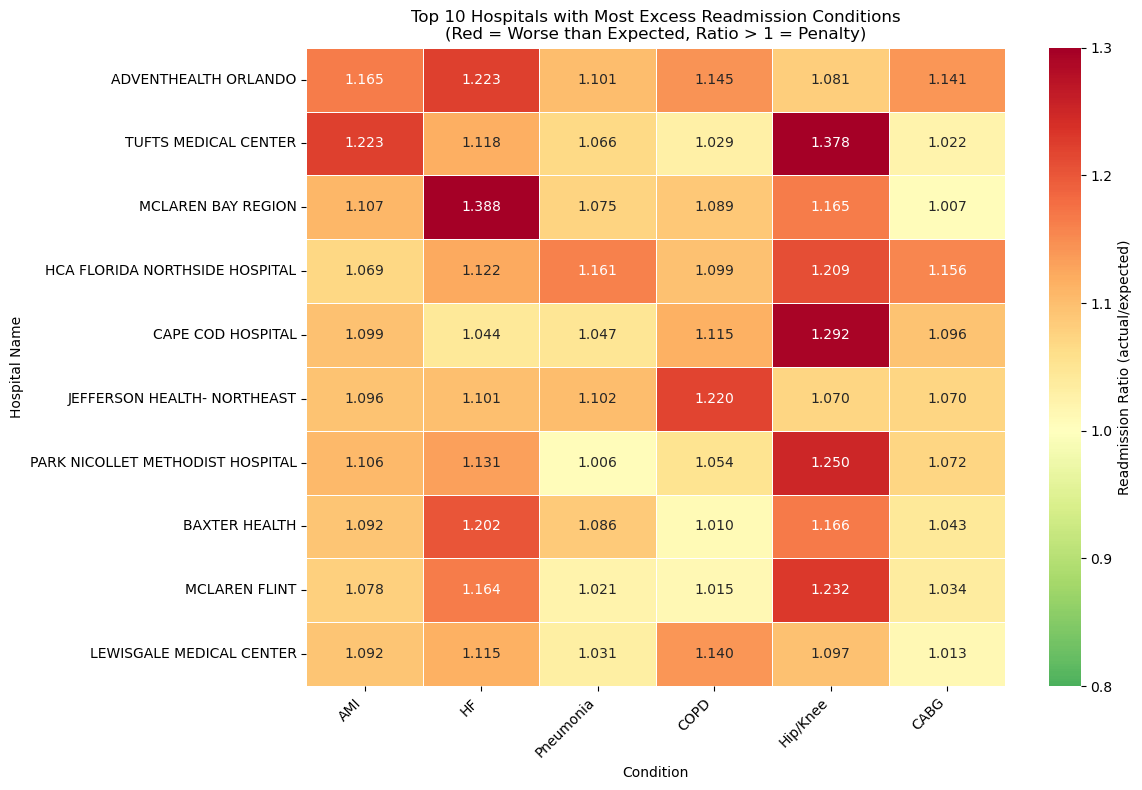

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, 
            annot=True,           
            fmt='.3f',            
            cmap='RdYlGn_r',      
            center=1.0,           
            vmin=0.8, vmax=1.3,   
            cbar_kws={'label': 'Readmission Ratio (actual/expected)'},
            linewidths=0.5,
            linecolor='white')

plt.title('Top 10 Hospitals with Most Excess Readmission Conditions\n(Red = Worse than Expected, Ratio > 1 = Penalty)')
plt.xlabel('Condition')
plt.ylabel('Hospital Name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### AND WITH THAT THE Q3 IS FULLY ANSWERED

#### SURPRISING INSIGHT : SADLY 470 HOSPITALS ACROSS THE US ARE GETTING PENALITIES 

They are all above 1.0 on four to six conditions that means they have a systemic problem

## Which hospitals have both high readmission rates AND high patient safety incidents? 
#### This question is a combination of our last calculation of readmission mean and PSI scores

PSI scores: from complications table which is a specific column comp_score_psi_90, it is a weighted composite score calculated by CMS using a more sophisticated method

In [86]:
general_info = pd.read_csv('general_info_cleaned.csv')
complications = pd.read_csv('complications_cleaned.csv')

readmissions['facility_id'] = readmissions['facility_id'].astype(str).str.zfill(6)
complications['facility_id'] = complications['facility_id'].astype(str).str.zfill(6)

high_psi_hospitals = complications[complications['comp_score_psi_90'] > 1].copy()

high_psi_hospitals = (
    high_psi_hospitals
        .sort_values('comp_score_psi_90', ascending=False)
        .reset_index(drop=True)
        .head(10)
        .merge(
    general_info[['facility_id', 'facility_name', 'state', 'hospital_type']],
    on='facility_id',
    how='left'
)
    
                    )

high_psi_hospitals[['facility_id', 'facility_name', 'state', 'comp_score_psi_90']]

,facility_id,facility_name,state,comp_score_psi_90
0,040020,ST BERNARDS MEDICAL CENTER,AR,3.16
1,080007,BEEBE MEDICAL CENTER,DE,3.07
2,250102,MISSISSIPPI BAPTIST MEDICAL CENTER,MS,2.43
3,330090,ARNOT OGDEN MEDICAL CENTER,NY,2.28
4,19048F,OVERTON BROOKS VA MEDICAL CENTER (SHREVEPORT),LA,2.25
5,250058,SOUTH CENTRAL REG MED CTR,MS,2.19
6,330094,COLUMBIA MEMORIAL HOSPITAL,NY,2.17
7,110043,ST JOSEPH'S HOSPITAL - SAVANNAH,GA,2.17
8,100212,MARION COMMUNTIY HOSPITAL,FL,2.12
9,330219,ERIE COUNTY MEDICAL CENTER,NY,2.09


In [87]:
high_readm_rate = readmissions[readmissions['conditions'] >= 1].copy()
high_readm_rate['avg_ratio'] = high_readm_rate[ratio_cols].mean(axis=1)

high_readm_rate = (high_readm_rate
    .sort_values('avg_ratio', ascending=False)
    .reset_index(drop=True)
    .head(10)
    .merge(
    general_info[['facility_id', 'facility_name', 'state', 'hospital_type']],
    on='facility_id',
    how='left'
)
                  )
high_readm_rate[['facility_id', 'facility_name', 'state', 'hospital_type', 'avg_ratio']]


,facility_id,facility_name,state,hospital_type,avg_ratio
0,390316,SURGICAL INSTITUTE OF READING,PA,Acute Care Hospitals,1.30970
1,190298,CHRISTUS CENTRAL LOUISIANA SURGICAL HOSPITAL,LA,Acute Care Hospitals,1.30370
2,450874,BAYLOR SURGICAL HOSPITAL AT LAS COLINAS,TX,Acute Care Hospitals,1.28930
3,520205,MIDWEST ORTHOPEDIC SPECIALTY HOSPITAL,WI,Acute Care Hospitals,1.26280
4,030112,ARIZONA ORTHOPEDIC AND SURGICAL SPECIALTY HOSP...,AZ,Acute Care Hospitals,1.25910
5,670069,METHODIST MCKINNEY HOSPITAL,TX,Acute Care Hospitals,1.25510
6,430090,SIOUX FALLS SPECIALTY HOSPITAL,SD,Acute Care Hospitals,1.25160
7,050030,OROVILLE HOSPITAL,CA,Acute Care Hospitals,1.24836
8,220105,WINCHESTER HOSPITAL,MA,Acute Care Hospitals,1.22116
9,100260,ST LUCIE MEDICAL CENTER,FL,Acute Care Hospitals,1.20138


In [88]:
readmissions['avg_ratio'] = readmissions[ratio_cols].mean(axis=1)
q4_combined = (
    complications[['facility_id', 'comp_score_psi_90']]
    .merge(
        readmissions[['facility_id', 'avg_ratio']],
        on='facility_id',
        how='inner'
    )
    .merge(
        general_info[['facility_id', 'facility_name', 'state', 'hospital_type']],
        on='facility_id',
        how='left'
    )
)
double_danger = (
    q4_combined[
        (q4_combined['comp_score_psi_90'] > 1) &
        (q4_combined['avg_ratio'] > 1.0)
    ]
    .sort_values(['comp_score_psi_90', 'avg_ratio'], ascending=[False, False])
    .reset_index(drop=True)
)

print(f"Double danger hospitals: {len(double_danger)}")
double_danger.head(10)

Double danger hospitals: 498


,facility_id,comp_score_psi_90,avg_ratio,facility_name,state,hospital_type
0,040020,3.16,1.077040,ST BERNARDS MEDICAL CENTER,AR,Acute Care Hospitals
1,080007,3.07,1.021083,BEEBE MEDICAL CENTER,DE,Acute Care Hospitals
2,250058,2.19,1.085120,SOUTH CENTRAL REG MED CTR,MS,Acute Care Hospitals
3,330094,2.17,1.006400,COLUMBIA MEMORIAL HOSPITAL,NY,Acute Care Hospitals
4,100212,2.12,1.074900,MARION COMMUNTIY HOSPITAL,FL,Acute Care Hospitals
5,330250,2.02,1.004800,CHAMPLAIN VALLEY PHYSICIANS HOSPITAL MEDICAL CTR,NY,Acute Care Hospitals
6,440048,2.01,1.098683,BAPTIST MEMORIAL HOSPITAL,TN,Acute Care Hospitals
7,010023,1.98,1.033267,BAPTIST MEDICAL CENTER SOUTH,AL,Acute Care Hospitals
8,230104,1.93,1.004000,HARPER UNIVERSITY HOSPITAL,MI,Acute Care Hospitals
9,510022,1.92,1.039500,CHARLESTON AREA MEDICAL CENTER,WV,Acute Care Hospitals


### AND WITH THAT THE Q4 IS FULLY ANSWERED
#### Key Finding

498 hospitals (out of 2828 with complete data) show simultaneous 
patient safety failures AND excess readmissions.

This means roughly 1 in 6 hospitals that can be evaluated on both 
dimensions has a systemic care quality problem — not just bad luck 
on one measure.

ST BERNARDS MEDICAL CENTER (AR) shows the most severe combination: 
PSI-90 score of 3.16 (3x above expected safety incidents) with 
readmission ratio of 1.077 across all 6 conditions.

#### AS THE SCATTER SHOWN BELLOW

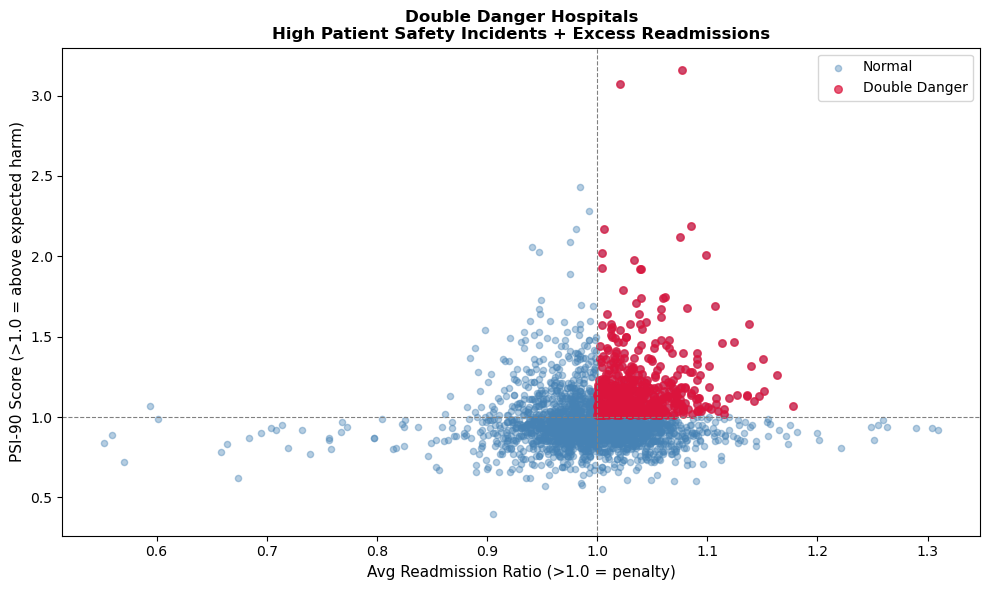

In [89]:
plt.figure(figsize=(10, 6))
plt.scatter(
    q4_combined['avg_ratio'],
    q4_combined['comp_score_psi_90'],
    alpha=0.4, color='steelblue', s=20, label='Normal'
)
plt.scatter(
    double_danger['avg_ratio'],
    double_danger['comp_score_psi_90'],
    alpha=0.7, color='crimson', s=30, label='Double Danger'
)
plt.axvline(x=1.0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('Avg Readmission Ratio (>1.0 = penalty)', fontsize=11)
plt.ylabel('PSI-90 Score (>1.0 = above expected harm)', fontsize=11)
plt.title('Double Danger Hospitals\nHigh Patient Safety Incidents + Excess Readmissions', 
          fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('double_danger.png', dpi=150, bbox_inches='tight')
plt.show()

### Which hospitals spend significantly above the national average but have worse-than-average outcomes?

#### Spending: per episode = total Medicare cost for one complete care episode including pre-admission, hospital stay, and 30-day post-discharge period.
High spending + poor outcomes is the worst combination


**med_complete_episode__total : Average spending per episode is the single most important column. This is the total average, price-standardized spending per episode.**

#### EPISODE : 

1. med_during_index_hospital_admission__...: Average spending on services provided during the patient's main hospital stay. This includes the cost of the room, nursing care, medications, and procedures.

2. med_1_to_3_days_prior_to_index_hospital_admission__...: Average spending on services provided in the 3 days leading up to the hospital admission, such as emergency room visits, doctor's office visits, or lab tests directly related to the reason for the hospitalization.

3. med_1_through_30_days_after_discharge_from_index_hospital_admission__...: Average spending on services provided in the 30 days after the patient is discharged. This includes follow-up visits, readmissions to other hospitals, or services like home health or skilled nursing facilities.

##### Then how high is the national average ? Or how high is "High spending"? 
It is simply when the spending > national median (or mean). This flags the top half (or top 25% if you want “significantly”)

##### How worse is the "worse-than-average outcomes"? is it something we already calculated ? or something? is it the hospitals that are  bad at readmissions or at patient safety ? mortality rates? patient experience? Or all together?

**To be fair when selecting the worse than national average outcome: We want to select the hospitals that are flagged "Worse" in mortality rates and PSI rates which we already did in Individual Hospital Quality. and then we add to this readmission ratio patient experience score. If we combine then the high spending it would definilty give us the worst hospitals.**

In [114]:
## BELOW AVERAGE PATIENT EXPERIENCE 
import pandas as pd
import numpy as np

general_info = pd.read_csv('general_info_cleaned.csv')
patient_experience = pd.read_csv('hcahps_cleaned.csv')

general_info['facility_id'] = general_info['facility_id'].astype(str).str.zfill(6)
patient_experience['facility_id'] = patient_experience['facility_id'].astype(str).str.zfill(6)

flag_list2 = [
    'hcahps_linear_h_clean_linear_score',
    'hcahps_linear_h_comp_1_linear_score',
    'hcahps_linear_h_comp_2_linear_score',
    'hcahps_linear_h_comp_5_linear_score',
    'hcahps_linear_h_comp_6_linear_score',
    'hcahps_linear_h_hsp_rating_linear_score',
    'hcahps_linear_h_quiet_linear_score',
    'hcahps_linear_h_recmnd_linear_score'
]

complete_reporters = patient_experience.dropna(subset=flag_list2)

exp_scores = pd.DataFrame({
    'facility_id': complete_reporters['facility_id'],
    'patient_exp_score': complete_reporters[flag_list2].mean(axis=1)
})

national_avg = exp_scores['patient_exp_score'].mean()
print(f"National average: {national_avg:.3f}")

poor_experience = (
    exp_scores[exp_scores['patient_exp_score'] < national_avg]
    .sort_values('patient_exp_score', ascending=True)
    .reset_index(drop=True)
    .merge(general_info[['facility_id', 'facility_name', 'state',
                'hospital_type', 'hospital_overall_rating']],
        on='facility_id',
        how='left'
    )
)

print(f"Hospitals with poor patient experience: {len(poor_experience)}")

poor_experience[[
    'facility_id', 'facility_name', 'state',
    'hospital_type', 'hospital_overall_rating', 'patient_exp_score'
]]

National average: 85.926
Hospitals with poor patient experience: 1562


,facility_id,facility_name,state,hospital_type,hospital_overall_rating,patient_exp_score
0,050771,COAST PLAZA HOSPITAL,CA,Acute Care Hospitals,1.0,66.750
1,050663,LOS ANGELES COMMUNITY HOSPITAL,CA,Acute Care Hospitals,2.0,68.500
2,050135,SOUTHERN CALIFORNIA HOSPITAL AT HOLLYWOOD,CA,Acute Care Hospitals,4.0,72.625
3,050030,OROVILLE HOSPITAL,CA,Acute Care Hospitals,1.0,72.875
4,050390,HEMET GLOBAL MEDICAL CENTER,CA,Acute Care Hospitals,1.0,72.875
...,...,...,...,...,...,...
1557,390079,ROBERT PACKER HOSPITAL,PA,Acute Care Hospitals,2.0,85.875
1558,340071,BETSY JOHNSON REGIONAL HOSPITAL,NC,Acute Care Hospitals,3.0,85.875
1559,210027,WESTERN MARYLAND REGIONAL MEDICAL CENTER,MD,Acute Care Hospitals,4.0,85.875
1560,310008,HOLY NAME MEDICAL CENTER,NJ,Acute Care Hospitals,4.0,85.875


In [115]:
## WORST FLAGGED HOSPITALS IN MORTALITY

general_info = pd.read_csv('general_info_cleaned.csv')
complications = pd.read_csv('complications_cleaned.csv')

flag_list_mort = [
    'comp_flag_mort_30_ami', 'comp_flag_mort_30_cabg', 'comp_flag_mort_30_copd',
    'comp_flag_mort_30_hf', 'comp_flag_mort_30_pn', 'comp_flag_mort_30_stk'
]

for col in flag_list_mort:
    complications[col] = complications[col].astype(str)

worse_counts = complications[flag_list_mort].apply(
    lambda row: sum('worse' in cell.lower() for cell in row),
    axis=1
)

worse_df_complications_mort = pd.DataFrame({
    'facility_id': complications['facility_id'],
    'worse_flags_mort': worse_counts
})

complications_mort = (
    worse_df_complications_mort
    .sort_values('worse_flags_mort', ascending=False)
    .reset_index(drop=True)
    .merge(general_info[['facility_id', 'facility_name', 'state', 'hospital_type']],on='facility_id',how='left')
)

complications_mort[['facility_id', 'facility_name', 'state', 'hospital_type', 'worse_flags_mort']]


,facility_id,facility_name,state,hospital_type,worse_flags_mort
0,270012,BENEFIS HOSPITALS INC,MT,Acute Care Hospitals,4
1,040036,BAPTIST HEALTH MEDICAL CENTER NORTH LITTLE ROCK,AR,Acute Care Hospitals,3
2,340143,CATAWBA VALLEY MEDICAL CENTER,NC,Acute Care Hospitals,3
3,250082,DELTA HEALTH SYSTEM - THE MEDICAL CENTER,MS,Acute Care Hospitals,3
4,180093,BAPTIST HEALTH DEACONESS MADISONVILLE,KY,Acute Care Hospitals,3
...,...,...,...,...,...
4179,171321,MEADE DISTRICT HOSPITAL,KS,Critical Access Hospitals,0
4180,171322,HAMILTON COUNTY HOSPITAL,KS,Critical Access Hospitals,0
4181,171325,GRAHAM COUNTY HOSPITAL,KS,Critical Access Hospitals,0
4182,171326,LOGAN COUNTY HOSPITAL,KS,Critical Access Hospitals,0


**This feels very confusing but tracking what is worst needs to recheck the code we used earlier , that means recalculating mortality rates, ensuring we want the hospitals that are flagged 'worse' and recalculating the poor patient experince score which is the scores that are less than the average scores. we are on the right track**

In [116]:
## MERGE DOUBLE DANGER WITH worse_flags_mort AND patient_exp_score
# ── STEP 1: get all facility_ids from each analysis ──────────────────

# Mortality — all hospitals with worse_flags_mort > 0, not just top 10
worst_mortality_ids = set(
    worse_df_complications_mort[
        worse_df_complications_mort['worse_flags_mort'] > 0
    ]['facility_id']
)

# Patient experience — all hospitals below national average
poor_experience_ids = set(
    exp_scores[exp_scores['patient_exp_score'] < national_avg]['facility_id']
)

# Safety + Readmissions — all double danger hospitals
double_danger_ids = set(double_danger['facility_id'])

print(f"Worst mortality hospitals    : {len(worst_mortality_ids)}")
print(f"Poor experience hospitals    : {len(poor_experience_ids)}")
print(f"Double danger hospitals      : {len(double_danger_ids)}")

# ── STEP 2: find hospitals in ALL THREE ──────────────────────────────
all_bad = worst_mortality_ids & poor_experience_ids & double_danger_ids
print(f"\nHospitals failing ALL dimensions: {len(all_bad)}")

# ── STEP 3: build the final table ────────────────────────────────────
systemic_worst = (
    worse_df_complications_mort[['facility_id', 'worse_flags_mort']]
    .merge(exp_scores[['facility_id', 'patient_exp_score']], on='facility_id', how='inner')
    .merge(double_danger[['facility_id', 'comp_score_psi_90', 'avg_ratio']], on='facility_id', how='inner')
    .merge(general_info[['facility_id', 'facility_name', 'state',
                          'hospital_type', 'hospital_overall_rating']],
           on='facility_id', how='left')
)

systemic_worst = (
    systemic_worst[systemic_worst['facility_id'].isin(all_bad)]
    .sort_values(['worse_flags_mort', 'comp_score_psi_90', 'avg_ratio'],
                 ascending=[False, False, False])
    .reset_index(drop=True)
)

print(f"\nFinal systemic worst table: {len(systemic_worst)} hospitals")
systemic_worst[[
    'facility_id', 'facility_name', 'state', 'hospital_type',
    'hospital_overall_rating', 'worse_flags_mort',
    'patient_exp_score', 'comp_score_psi_90', 'avg_ratio'
]]

Worst mortality hospitals    : 379
Poor experience hospitals    : 1562
Double danger hospitals      : 498

Hospitals failing ALL dimensions: 47

Final systemic worst table: 47 hospitals


,facility_id,facility_name,state,hospital_type,hospital_overall_rating,worse_flags_mort,patient_exp_score,comp_score_psi_90,avg_ratio
0,450133,MIDLAND MEMORIAL HOSPITAL,TX,Acute Care Hospitals,1.0,3,85.250,1.12,1.017160
1,210040,NORTHWEST HOSPITAL CENTER,MD,Acute Care Hospitals,2.0,2,82.375,1.30,1.032425
2,100022,JACKSON HEALTH SYSTEM,FL,Acute Care Hospitals,1.0,2,84.500,1.30,1.015450
3,010006,NORTH ALABAMA MEDICAL CENTER,AL,Acute Care Hospitals,2.0,2,82.000,1.14,1.000217
4,150012,SAINT JOSEPH REGIONAL MEDICAL CENTER,IN,Acute Care Hospitals,2.0,2,84.000,1.12,1.001220
5,250048,ST DOMINIC-JACKSON MEMORIAL HOSPITAL,MS,Acute Care Hospitals,1.0,2,83.750,1.09,1.028100
6,100212,MARION COMMUNTIY HOSPITAL,FL,Acute Care Hospitals,1.0,1,82.875,2.12,1.074900
7,510022,CHARLESTON AREA MEDICAL CENTER,WV,Acute Care Hospitals,1.0,1,85.250,1.92,1.039500
8,010040,GADSDEN REGIONAL MEDICAL CENTER,AL,Acute Care Hospitals,1.0,1,82.625,1.58,1.038917
9,110064,PIEDMONT COLUMBUS REGIONAL MIDTOWN,GA,Acute Care Hospitals,1.0,1,83.250,1.58,1.012875


**Now we have the worst hospitals acording all dimentions but this is not the end , we wanna check the high spending to extract the worst hospitals that spends MORE than the national average, as a reminder the high spending is spending > avg(spending)**

In [117]:
## BELOW AVERAGE PATIENT EXPERIENCE 
import pandas as pd
import numpy as np

general_info = pd.read_csv('general_info_cleaned.csv')
spending = pd.read_csv('medicare_cleaned.csv')

general_info['facility_id'] = general_info['facility_id'].astype(str).str.zfill(6)
spending['facility_id'] = spending['facility_id'].astype(str).str.zfill(6)

# calculate national average
national_avg_spending = spending['med_complete_episode__total'].mean()
print(f"National average spending: ${national_avg_spending:,.0f}")

# filter hospitals above average
high_spending = (
    spending[spending['med_complete_episode__total'] > national_avg_spending]
    [['facility_id', 'med_complete_episode__total']]
    .sort_values('med_complete_episode__total', ascending=False)
    .reset_index(drop=True)
    .merge(
        general_info[['facility_id', 'facility_name', 'state',
                      'hospital_type', 'hospital_overall_rating']],
        on='facility_id',
        how='left'
    )
)

print(f"Hospitals above national average spending: {len(high_spending)}")

high_spending[[
    'facility_id', 'facility_name', 'state',
    'hospital_type', 'hospital_overall_rating',
    'med_complete_episode__total'
]]

National average spending: $25,693
Hospitals above national average spending: 1441


,facility_id,facility_name,state,hospital_type,hospital_overall_rating,med_complete_episode__total
0,060124,ORTHOCOLORADO HOSP AT ST ANTHONY MED CAMPUS,CO,Acute Care Hospitals,NaN,45654
1,280133,"NEBRASKA SPINE HOSPITAL, LLC",NE,Acute Care Hospitals,NaN,44693
2,050738,GREATER EL MONTE COMMUNITY HOSPITAL,CA,Acute Care Hospitals,2.0,44537
3,670059,CHI ST LUKES LAKESIDE HOSPITAL,TX,Acute Care Hospitals,NaN,43956
4,370206,OKLAHOMA SPINE HOSPITAL,OK,Acute Care Hospitals,NaN,43845
...,...,...,...,...,...,...
1436,500002,PROVIDENCE ST MARY MEDICAL CENTER,WA,Acute Care Hospitals,3.0,25706
1437,490022,MARY WASHINGTON HOSPITAL,VA,Acute Care Hospitals,2.0,25705
1438,160045,ST LUKES HOSPITAL,IA,Acute Care Hospitals,4.0,25702
1439,370089,NORTHEASTERN HEALTH SYSTEM,OK,Acute Care Hospitals,2.0,25699


In [118]:
high_spending_ids = set(high_spending['facility_id'])

systemic_worst_ids = set(systemic_worst['facility_id'])

all_dimensions_high_spending = high_spending_ids & systemic_worst_ids
print(f"Hospitals failing ALL dimensions AND spending above average: {len(all_dimensions_high_spending)}")

worst_and_expensive = (
    systemic_worst[systemic_worst['facility_id'].isin(all_dimensions_high_spending)]
    .merge(
        high_spending[['facility_id', 'med_complete_episode__total']],
        on='facility_id',
        how='left'
    )
    .sort_values(['med_complete_episode__total', 'worse_flags_mort',
                  'comp_score_psi_90', 'avg_ratio'],
                 ascending=[False, False, False, False])
    .reset_index(drop=True)
)

print(f"\nFinal table shape: {worst_and_expensive.shape}")
worst_and_expensive[[
    'facility_id', 'facility_name', 'state', 'hospital_type',
    'hospital_overall_rating', 'worse_flags_mort',
    'patient_exp_score', 'comp_score_psi_90',
    'avg_ratio', 'med_complete_episode__total'
]]

Hospitals failing ALL dimensions AND spending above average: 35

Final table shape: (35, 10)


,facility_id,facility_name,state,hospital_type,hospital_overall_rating,worse_flags_mort,patient_exp_score,comp_score_psi_90,avg_ratio,med_complete_episode__total
0,310092,CAPITAL HEALTH REGIONAL MEDICAL CENTER,NJ,Acute Care Hospitals,2.0,1,78.250,1.21,1.004733,35846
1,100022,JACKSON HEALTH SYSTEM,FL,Acute Care Hospitals,1.0,2,84.500,1.30,1.015450,33532
2,310038,ROBERT WOOD JOHNSON UNIVERSITY HOSPITAL,NJ,Acute Care Hospitals,2.0,1,84.375,1.14,1.126533,32849
3,050056,ANTELOPE VALLEY HOSPITAL,CA,Acute Care Hospitals,1.0,1,78.125,1.07,1.021950,32544
4,110064,PIEDMONT COLUMBUS REGIONAL MIDTOWN,GA,Acute Care Hospitals,1.0,1,83.250,1.58,1.012875,31556
5,310118,HUDSON REGIONAL HOSPITAL,NJ,Acute Care Hospitals,1.0,1,84.375,1.15,1.001150,31515
6,290046,SPRING VALLEY HOSPITAL MEDICAL CENTER,NV,Acute Care Hospitals,2.0,1,81.875,1.03,1.001950,31376
7,180010,SAINT JOSEPH HOSPITAL,KY,Acute Care Hospitals,2.0,1,83.375,1.35,1.049567,31318
8,450133,MIDLAND MEMORIAL HOSPITAL,TX,Acute Care Hospitals,1.0,3,85.250,1.12,1.017160,31214
9,030065,BANNER DESERT MEDICAL CENTER,AZ,Acute Care Hospitals,2.0,1,80.125,1.23,1.032920,30911


### AND WITH THAT THE Q5 IS FULLY ANSWERED

#### Key Finding — Q5 : The Worst of the Worst

35 hospitals out of 5,426 (0.6%) are simultaneously:
- Flagged worse than national rate on mortality
- Below average on patient experience  
- Above expected on patient safety incidents (PSI-90)
- Penalized for excess readmissions
- Spending above the national average per episode

These hospitals are not just underperforming — they are 
actively harming patients AND costing the healthcare system 
more than their peers. High spending here is not buying 
better outcomes. It is the worst possible combination.

In [120]:
worst_and_expensive.to_csv('worst_expensive_hospitals_all_dimensions.csv', index=False)
print("Saved")

Saved
